<h4><mark>GROUP 264 - Members with Contribution Details </mark></h4>

<table border="1" style="border-collapse: collapse; text-align: center;">
  <tr>
    <th>S.NO</th>
    <th>NAME</th>
    <th>BITS ID</th>
    <th>CONTRIBUTION %</th>
  </tr>
  <tr>
    <td>1</td>
    <td>Nalla Manoj Kumar</td>
    <td>2024AC05141</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>2</td>
    <td>D Mallikarjuna Reddy</td>
    <td>2024AC05653</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>3</td>
    <td>Sajjala Ashok Reddy</td>
    <td>2024AC05829</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>4</td>
    <td>Adurti Sai Venkatesh</td>
    <td>2024AC05968</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>5</td>
    <td>M Satish Kumar</td>
    <td>2024AD05320</td>
    <td>100 %</td>
  </tr>
</table>


<h1 style="color:Red"><u><b>Maze-Navigating Robot Agent</b></u></h1>

<h3 style="color: #2c3e50; margin-bottom: 10px;"><b>PEAS</b></h3>

<table border="1" style="border-collapse: collapse; width: 100%;">
  <tr style="background-color: #ffff00;">
    <th style="text-align: left; padding: 4px; vertical-align: top; width: 25%;"><b>Component</b></th>
    <th style="text-align: left; padding: 4px; vertical-align: top; width: 75%;"><b>Description</b></th>
  </tr>

  <tr>
    <td style="text-align: left; padding: 4px; vertical-align: top;"><b>Performance Measure</b></td>
    <td style="text-align: left; padding: 4px;">
      - Minimize <b><i>total path cost</i></b> from Start to Finish<br>
      - Avoid unnecessary <b><i>East moves</i></b> to reduce sunlight penalty<br>
      - Reach goal in <b><i>shortest safe path</i></b>
    </td>
  </tr>

  <tr style="background-color: #f9f9f9;">
    <td style="text-align: left; padding: 4px; vertical-align: top;"><b>Environment</b></td>
    <td style="text-align: left; padding: 4px;">
      - Grid-based maze with static obstacles (walls) and <b><i>size 6x7</i></b> (fully observable)<br>
      - Movement allowed in 4 directions: N, S, E, W; no change in defined walls (<b>static</b>)<br>
      - Sunlight intensity affects East direction (adds cost); no uncertain moves, limited (countable) steps to reach goal<br><br>
      <b><i>- Static / Fully observable / Discrete / Deterministic / Single Agent</i></b>
    </td>
  </tr>

  <tr>
    <td style="text-align: left; padding: 4px; vertical-align: top;"><b>Actuators</b></td>
    <td style="text-align: left; padding: 4px;">
      - <b><i>Motors/wheels</i></b> to move the robot in 4 directions (N, S, E, W)<br>
      - Mechanism to <i>execute <b>transition functions</b></i> between adjacent cells
    </td>
  </tr>

  <tr style="background-color: #f9f9f9;">
    <td style="text-align: left; padding: 4px; vertical-align: top;"><b>Sensors</b></td>
    <td style="text-align: left; padding: 4px;">
      - <b><i>Vision or proximity</i></b> sensors to detect walls/obstacles<br>
      - <b><i>Light sensors</i></b> to detect East direction exposure (sunlight penalty)<br><br>
      - <i><b>current cell (position), maze configuration map, internal memory to store cost details, queue</b></i>
    </td>
  </tr>
</table>



# Code Part

<h2 style="color:purple"><u><b>Given constraints</b></u></h2>

##### - 6x7 Maze with walls (indexing from 0)
##### - Start (3,0) && Goal (3,6)
##### - Possible moves - North, South, West, East (given compass)
##### - Each move cost +3 and towards East incurre +5 additional cost
##### - Manhattan distance for heuristic cost calculation

<h2 style="color:orange"><u><b>Implementing  A* algorithm</b></u></h2>

<h3 style="color:darkcyan"><u><b>Method -1: [Static Inputs]</b></u></h3> 
    Calculating path cost and heuristic cost manually and assign as static variables
<h3 style="color:darkcyan"><u><b>Method-2: [Dynamic Inputs]</b></u></h3> 
    Calculating both path costs using python functions

<h2 style="color:darkcyan"><u><b>Method -1: Implementation</b></u></h2> 

###### Representing the maze with actual path costs
###### Cost is calculated as per the cell possible moves using given constraints

### Inputs

In [2]:
#Maze
Graph_nodes = {
    '0_0': [('1_0', 3), ('0_1', 8)],
    '0_1': [('0_0', 3), ('0_2', 8), ('1_1', 3)],
    '0_2': [('0_1', 3), ('1_2', 3) ],
    '0_3': [('1_3', 3), ('0_4', 8)],
    '0_4': [('0_3', 3), ('1_4', 3)],
    '0_5': [('1_5', 3), ('0_6', 8)],
    '0_6': [('0_5', 3), ('1_6', 3)],
    '1_0': [('0_0', 3), ('2_0', 3)],
    '1_1': [('2_1', 3), ('0_1', 3)],
    '1_2': [('0_2', 3), ('2_2', 3)],
    '1_3': [('2_3', 3), ('0_3', 3)],
    '1_4': [('0_4', 3), ('2_4', 3)],
    '1_5': [('2_5', 3), ('0_5', 3)],
    '1_6': [('0_6', 3), ('2_6', 3)],
    '2_0': [('1_0', 3)],
    '2_1': [('3_1', 3), ('1_1', 3)],
    '2_2': [('1_2', 3), ('3_2', 3)],
    '2_3': [('3_3', 3), ('1_3', 3)],
    '2_4': [('1_4', 3), ('3_4', 3)],
    '2_5': [('3_5', 3), ('1_5', 3)],
    '2_6': [('1_6', 3), ('3_6', 3)],
    '3_0': [('4_0', 3), ('3_1', 8)],
    '3_1': [('3_0', 3), ('2_1', 3)],
    '3_2': [('2_2', 3), ('4_2', 3)],
    '3_3': [('4_3', 3), ('2_3', 3)],
    '3_4': [('2_4', 3), ('4_4', 3)],
    '3_5': [('4_5', 3), ('2_5', 3)],
    '3_6': [('2_6', 3), ('4_6', 3)],
    '4_0': [('3_0', 3), ('5_0', 3)],
    '4_1': [('4_2', 8)],
    '4_2': [('3_2', 3), ('4_3', 8), ('4_1', 3)],
    '4_3': [('4_2', 3), ('3_3', 3)],
    '4_4': [('3_4', 3), ('4_5', 8)],
    '4_5': [('4_4', 3), ('3_5', 3)],
    '4_6': [('3_6', 3), ('5_6', 3)],
    '5_0': [('4_0', 3), ('5_1', 8)],
    '5_1': [('5_0', 3), ('5_2', 8)],
    '5_2': [('5_1', 3), ('5_3', 8)],
    '5_3': [('5_2', 3), ('5_4', 8)],
    '5_4': [('5_3', 3), ('5_5', 8)],
    '5_5': [('5_4', 3), ('5_6', 8)],
    '5_6': [('5_5', 3), ('4_6', 3)],

}

##### Heuristic function - gives the h(n) of a cell
##### Cost is calculated (Manahattan distance from goal) and assigned

In [94]:
#this function returns heuristic distance
def heuristic(n):
    H_dist = {
        '0_0': 9,
        '0_1': 8,
        '0_2': 7,
        '0_3': 6,
        '0_4': 5,
        '0_5': 4,
        '0_6': 3,
        '1_0': 8,
        '1_1': 7,
        '1_2': 6,
        '1_3': 5,
        '1_4': 4,
        '1_5': 3,
        '1_6': 2,
        '2_0': 7,
        '2_1': 6,
        '2_2': 5,
        '2_3': 4,
        '2_4': 3,
        '2_5': 2,
        '2_6': 1,
        '3_0': 6,
        '3_1': 5,
        '3_2': 4,
        '3_3': 3,
        '3_4': 2,
        '3_5': 1,
        '3_6': 0,
        '4_0': 7,
        '4_1': 6,
        '4_2': 5,
        '4_3': 4,
        '4_4': 3,
        '4_5': 2,
        '4_6': 1,
        '5_0': 8,
        '5_1': 7,
        '5_2': 6,
        '5_3': 5,
        '5_4': 4,
        '5_5': 3,
        '5_6': 2,
    }
    return H_dist[n]

###### Fuction to return neighbor and its distance of given cell

In [95]:
#get neighbours and the costs
def get_neighbors(v):
    if v in Graph_nodes:
        return Graph_nodes[v]
    else:
        return None

##### A* Seach - Code

In [5]:
def aStarAlgo(start_node, stop_node,w):
    print(start_node,"starting node")  ;
    open_set = set()
    open_set.add(start_node)
    closed_set = set()
    print(closed_set,"closed empty set") ;
    g = {}               #store distance from starting node
    parents = {}         # parents contains an adjacency map of all nodes
    #intial distance of starting node from itself is zero
    g[start_node] = 0
    #start_node is root node i.e it has no parent nodes
    #so start_node is set to its own parent node
    parents[start_node] = start_node
    while len(open_set) > 0:              # checking starting node to be not empty
        n = None                          # node with lowest f() is found
        print(open_set ,">>>open list ")
        for v in open_set:
            print("checking for node",v, "from open list\n")
            if n == None or g[v] + heuristic(v) < g[n] + heuristic(n)*w :
                n = v
                print(g[n],"is g(n) and", heuristic(n) ,",", w, "are h(n), w  for the lowet function node",n,"")
                print("f(n) for the node ",v," is ", g[n] + heuristic(n)*w,"\n")
        if n == stop_node or Graph_nodes[n] == None:
            pass
        else:
            for (m, weight) in get_neighbors(n):
                #nodes 'm' not in first and last set are added to first
                #n is set its parent
                if m not in open_set and m not in closed_set:
                    open_set.add(m)
                    parents[m] = n
                    g[m] = g[n] + weight
                #for each node m,compare its distance from start i.e g(m) to the
                #from start through n node
                else:
                    if g[m] > g[n] + weight:
                        #update g(m)
                        g[m] = g[n] + weight
                        #change parent of m to n
                        parents[m] = n
                        #if m in closed set,remove and add to open
                        if m in closed_set:
                            closed_set.remove(m)
                            open_set.add(m)
        if n == None:
            print('Path does not exist!')
            return None

        # if the current node is the stop_node
        # then we begin reconstructin the path from it to the start_node
        if n == stop_node:
            path = []
            while parents[n] != n:
                path.append(n)
                n = parents[n]
            path.append(start_node)
            path.reverse()
            print('Path found: {}'.format(path))
            return path
        # remove n from the open_list, and add it to closed_list
        # because all of his neighbors were inspected
        open_set.remove(n)
        closed_set.add(n)
    print('Path does not exist!')
    return None


## Calling the A* function

<h2 style="color:purple"><u><b> Scenario 1 :: w= 1.0 </b></u></h2>



In [6]:
#1.0 represents weight from scenario-1
aStarAlgo('3_0', '3_6',1.0)

3_0 starting node
set() closed empty set
{'3_0'} >>>open list 
checking for node 3_0 from open list

0 is g(n) and 6 , 1.0 are h(n), w  for the lowet function node 3_0 
f(n) for the node  3_0  is  6.0 

{'4_0', '3_1'} >>>open list 
checking for node 4_0 from open list

3 is g(n) and 7 , 1.0 are h(n), w  for the lowet function node 4_0 
f(n) for the node  4_0  is  10.0 

checking for node 3_1 from open list

{'5_0', '3_1'} >>>open list 
checking for node 5_0 from open list

6 is g(n) and 8 , 1.0 are h(n), w  for the lowet function node 5_0 
f(n) for the node  5_0  is  14.0 

checking for node 3_1 from open list

8 is g(n) and 5 , 1.0 are h(n), w  for the lowet function node 3_1 
f(n) for the node  3_1  is  13.0 

{'5_0', '2_1'} >>>open list 
checking for node 5_0 from open list

6 is g(n) and 8 , 1.0 are h(n), w  for the lowet function node 5_0 
f(n) for the node  5_0  is  14.0 

checking for node 2_1 from open list

{'5_1', '2_1'} >>>open list 
checking for node 5_1 from open list

14 

['3_0', '4_0', '5_0', '5_1', '5_2', '5_3', '5_4', '5_5', '5_6', '4_6', '3_6']

<h2 style="color:purple"><u><b> Scenario 2 :: w= 2.5 </b></u></h2>


In [7]:
#2.5 represents weight from scenario-1
aStarAlgo('3_0', '3_6',2.5)

3_0 starting node
set() closed empty set
{'3_0'} >>>open list 
checking for node 3_0 from open list

0 is g(n) and 6 , 2.5 are h(n), w  for the lowet function node 3_0 
f(n) for the node  3_0  is  15.0 

{'4_0', '3_1'} >>>open list 
checking for node 4_0 from open list

3 is g(n) and 7 , 2.5 are h(n), w  for the lowet function node 4_0 
f(n) for the node  4_0  is  20.5 

checking for node 3_1 from open list

8 is g(n) and 5 , 2.5 are h(n), w  for the lowet function node 3_1 
f(n) for the node  3_1  is  20.5 

{'4_0', '2_1'} >>>open list 
checking for node 4_0 from open list

3 is g(n) and 7 , 2.5 are h(n), w  for the lowet function node 4_0 
f(n) for the node  4_0  is  20.5 

checking for node 2_1 from open list

11 is g(n) and 6 , 2.5 are h(n), w  for the lowet function node 2_1 
f(n) for the node  2_1  is  26.0 

{'4_0', '1_1'} >>>open list 
checking for node 4_0 from open list

3 is g(n) and 7 , 2.5 are h(n), w  for the lowet function node 4_0 
f(n) for the node  4_0  is  20.5 

che

['3_0', '4_0', '5_0', '5_1', '5_2', '5_3', '5_4', '5_5', '5_6', '4_6', '3_6']

<h2 style="color:darkcyan"><u><b>Method -2: Implementation</b></u></h2> 

In [44]:
#Modules
import heapq
import matplotlib.pyplot as plt
import pandas as pd

##### Representing given Maze

###### Each cell is represented as (row, col): { 'N': bool, 'S': bool, 'E': bool, 'W': bool }
###### 'True' means the wall is OPEN & 'False' means CLOSED in that direction

### Inputs

In [9]:
maze = {
    (0, 0): {'E': True,  'W': False, 'N': False, 'S': True},
    (0, 1): {'E': True,  'W': True,  'N': False, 'S': True},
    (0, 2): {'E': False, 'W': True,  'N': False, 'S': True},
    (0, 3): {'E': True,  'W': False, 'N': False, 'S': True},
    (0, 4): {'E': False, 'W': True,  'N': False, 'S': True},
    (0, 5): {'E': True,  'W': False, 'N': False, 'S': True},
    (0, 6): {'E': False, 'W': True,  'N': False, 'S': True},

    (1, 0): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 1): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 2): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 3): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 4): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 5): {'E': False, 'W': False, 'N': True,  'S': True},
    (1, 6): {'E': False, 'W': False, 'N': True,  'S': True},

    (2, 0): {'E': False, 'W': False, 'N': True,  'S': False},
    (2, 1): {'E': False, 'W': False, 'N': True,  'S': True},
    (2, 2): {'E': False, 'W': False, 'N': True,  'S': True},
    (2, 3): {'E': False, 'W': False, 'N': True,  'S': True},
    (2, 4): {'E': False, 'W': False, 'N': True,  'S': True},
    (2, 5): {'E': False, 'W': False, 'N': True,  'S': True},
    (2, 6): {'E': False, 'W': False, 'N': True,  'S': True},

    (3, 0): {'E': True,  'W': True,  'N': False, 'S': True},
    (3, 1): {'E': False, 'W': True,  'N': True,  'S': False},
    (3, 2): {'E': False, 'W': False, 'N': True,  'S': True},
    (3, 3): {'E': False, 'W': False, 'N': True,  'S': True},
    (3, 4): {'E': False, 'W': False, 'N': True,  'S': True},
    (3, 5): {'E': False, 'W': False, 'N': True,  'S': True},
    (3, 6): {'E': True,  'W': False, 'N': True,  'S': True},

    (4, 0): {'E': False, 'W': False, 'N': True,  'S': True},
    (4, 1): {'E': True,  'W': False, 'N': False, 'S': False},
    (4, 2): {'E': True,  'W': True,  'N': True,  'S': False},
    (4, 3): {'E': False, 'W': True,  'N': True,  'S': False},
    (4, 4): {'E': True,  'W': False, 'N': True,  'S': False},
    (4, 5): {'E': False, 'W': True,  'N': True,  'S': False},
    (4, 6): {'E': False, 'W': False, 'N': True,  'S': True},

    (5, 0): {'E': True,  'W': False, 'N': True,  'S': False},
    (5, 1): {'E': True,  'W': True,  'N': False, 'S': False},
    (5, 2): {'E': True,  'W': True,  'N': False, 'S': False},
    (5, 3): {'E': True,  'W': True,  'N': False, 'S': False},
    (5, 4): {'E': True,  'W': True,  'N': False, 'S': False},
    (5, 5): {'E': True,  'W': True,  'N': False, 'S': False},
    (5, 6): {'E': False, 'W': True,  'N': True,  'S': False},
}


#### Visualization Function

In [37]:
def draw_maze(maze, rows=6, cols=7, start=(3, 0), goal=(3, 6)):
    fig, ax = plt.subplots(figsize=(6, 4))

    for (r, c), walls in maze.items():
        x, y = c, rows - 1 - r  # Origin at top-left

        # Draw walls (red solid if closed, gray dotted if open)
        if walls.get('N', False):
            ax.plot([x, x + 1], [y + 1, y + 1], color='gray', linestyle='dotted')
        else:
            ax.plot([x, x + 1], [y + 1, y + 1], color='red')

        if walls.get('S', False):
            ax.plot([x, x + 1], [y, y], color='gray', linestyle='dotted')
        else:
            ax.plot([x, x + 1], [y, y], color='red')

        if walls.get('W', False):
            ax.plot([x, x], [y, y + 1], color='gray', linestyle='dotted')
        else:
            ax.plot([x, x], [y, y + 1], color='red')

        if walls.get('E', False):
            ax.plot([x + 1, x + 1], [y, y + 1], color='gray', linestyle='dotted')
        else:
            ax.plot([x + 1, x + 1], [y, y + 1], color='red')

        # Add cell coordinates text
        ax.text(x + 0.5, y + 0.5, f"({r},{c})", ha='center', va='center', fontsize=8)

    # Highlight Start and Goal
    sx, sy = start[1], rows - 1 - start[0]
    gx, gy = goal[1], rows - 1 - goal[0]
    ax.add_patch(plt.Rectangle((sx, sy), 1, 1, color='green', alpha=0.3))
    ax.add_patch(plt.Rectangle((gx, gy), 1, 1, color='blue', alpha=0.3))

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_aspect('equal')
    ax.grid(False)
    plt.title("Given Maze - Green cell (START), Blue cell (GOAL)", fontsize=14)
    plt.show()

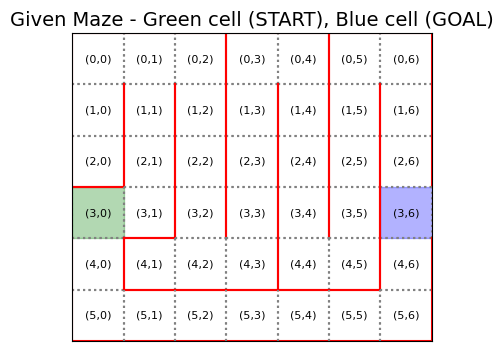

In [38]:
#Run the Visualization function on 'maze'
draw_maze(maze)

#### Given constraints as variables

### Inputs

In [103]:
W = 1.0  # Heuristic weight

In [104]:
rows, cols = 6, 7
COST_MOVE = 3
COST_EAST_PENALTY = 5

DIRECTIONS = {
    'N': (-1, 0),
    'S': (1, 0),
    'W': (0, -1),
    'E': (0, 1)
}


### Defining the functions

In [105]:
#Manhattan calculation function
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [106]:
def a_star_maze(maze, start, goal, W, rows, cols):
    open_set = []  # Min-heap priority queue for (f_score, cell)
    heapq.heappush(open_set, (0, start))  # Push start node with f=0

    came_from = {}  # Dictionary to store the path (child -> parent)
    g_score = {start: 0}  # Cost from start node to each node (g(n))
    closed_set = set()  # Set to store already evaluated (expanded) nodes
    step_costs = []  # List to store move costs for reporting
    step_num = 1  # Step counter for printing progress

    while open_set:
        f_current, current = heapq.heappop(open_set)  # Get the node with lowest f(n) from the open list

        if current in closed_set:
            continue  # Skip if node was already expanded

        closed_set.add(current)  # Mark current node as expanded

        g = g_score[current]  # Get g(n): actual cost from start to current
        h = heuristic(current, goal)  # Compute h(n): estimated cost from current to goal
        f = g + W * h  # Compute f(n) = g(n) + W * h(n); W is the weight multiplier

        print(f"Step {step_num}: Current = {current}, g(n)={g}, h(n)={h}, f(n)={f}")  # Print current state
        step_num += 1

        if current == goal:
            # If goal is reached, reconstruct the path
            path = []
            total_cost = g_score[goal]  # Final cost from start to goal
            while current in came_from:
                prev = came_from[current]
                path.append(current)

                direction = (current[0] - prev[0], current[1] - prev[1])  # Determine direction moved
                for d, (dy, dx) in DIRECTIONS.items():  # Match direction with direction key
                    if (dy, dx) == direction:
                        cost = COST_MOVE + (COST_EAST_PENALTY if d == 'E' else 0)  # Calculate move cost
                        step_costs.append((prev, current, cost))  # Save move details
                        break
                current = prev  # Move one step back in the path
            path.append(start)  # Add the start node to path
            return path[::-1], step_costs[::-1], total_cost, g_score  # Return reversed path and details

        # Explore all valid directions from the current node
        for dir_key, (dy, dx) in DIRECTIONS.items():
            if maze.get(current, {}).get(dir_key, False):  # Check if the direction is open
                neighbor = (current[0] + dy, current[1] + dx)  # Compute neighbor position

                if 0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols:  # Ensure within bounds
                    move_cost = COST_MOVE + (COST_EAST_PENALTY if dir_key == 'E' else 0)  # Apply east penalty if needed
                    tentative_g = g_score[current] + move_cost  # Tentative cost to reach neighbor

                    if tentative_g < g_score.get(neighbor, float('inf')):  # Only update if better path found
                        came_from[neighbor] = current  # Update path
                        g_score[neighbor] = tentative_g  # Update cost
                        f_neighbor = tentative_g + W * heuristic(neighbor, goal)  # Compute f(n) for neighbor
                        heapq.heappush(open_set, (f_neighbor, neighbor))  # Push neighbor into open list

    return None, [], float('inf'), g_score  # If goal not reachable, return failure


In [107]:
def draw_maze_with_path(maze, path, rows=6, cols=7):
    fig, ax = plt.subplots(figsize=(6, 4))  # Create a matplotlib figure and axis for plotting

    for (r, c), walls in maze.items():  # Loop through each cell and its wall info
        x, y = c, rows - 1 - r  # Convert grid coordinates to plot coordinates (invert y-axis)

        # Draw solid black lines for closed walls
        if not walls.get('N', False): ax.plot([x, x+1], [y+1, y+1], 'k')  # North wall
        if not walls.get('S', False): ax.plot([x, x+1], [y, y], 'k')      # South wall
        if not walls.get('W', False): ax.plot([x, x], [y, y+1], 'k')      # West wall
        if not walls.get('E', False): ax.plot([x+1, x+1], [y, y+1], 'k')  # East wall

        # Display the cell coordinates inside each cell (for reference)
        ax.text(x+0.5, y+0.5, f'({r},{c})', ha='center', va='center', fontsize=8, color='blue')

    if path:
        # Highlight the entire path (excluding start and goal) with green circles
        for (r, c) in path:
            x, y = c, rows - 1 - r
            ax.add_patch(plt.Circle((x + 0.5, y + 0.5), 0.2, color='green'))

        # Highlight start node with orange
        sx, sy = path[0][1], rows - 1 - path[0][0]
        ax.add_patch(plt.Circle((sx + 0.5, sy + 0.5), 0.2, color='orange', label='Start'))

        # Highlight goal node with red
        gx, gy = path[-1][1], rows - 1 - path[-1][0]
        ax.add_patch(plt.Circle((gx + 0.5, gy + 0.5), 0.2, color='red', label='Goal'))

    # Set plot limits and visual layout
    ax.set_xlim(0, cols)  # X-axis from 0 to number of columns
    ax.set_ylim(0, rows)  # Y-axis from 0 to number of rows
    ax.set_aspect('equal')  # Keep square cells

    # Add gridlines and ticks for clarity
    ax.set_xticks(range(cols + 1))
    ax.set_yticks(range(rows + 1))
    ax.grid(True)

    plt.title("A* Pathfinding (Manhattan Heuristic, w={W})")  # Title for the plot
    plt.legend()  # Display legend for Start and Goal
    plt.show()  # Show the final visual output


<h2 style="color:purple"><u><b> Scenario 1 :: w= 1.0 </b></u></h2>


## Calling A* function

In [108]:
start = (3, 0)
goal = (3, 6)

print("weight",W)
# three returned values
path, steps, total, scores = a_star_maze(maze, start, goal, W=1.0, rows=rows, cols=cols)

weight 1.0
Step 1: Current = (3, 0), g(n)=0, h(n)=6, f(n)=6.0
Step 2: Current = (4, 0), g(n)=3, h(n)=7, f(n)=10.0
Step 3: Current = (3, 1), g(n)=8, h(n)=5, f(n)=13.0
Step 4: Current = (5, 0), g(n)=6, h(n)=8, f(n)=14.0
Step 5: Current = (2, 1), g(n)=11, h(n)=6, f(n)=17.0
Step 6: Current = (1, 1), g(n)=14, h(n)=7, f(n)=21.0
Step 7: Current = (5, 1), g(n)=14, h(n)=7, f(n)=21.0
Step 8: Current = (0, 1), g(n)=17, h(n)=8, f(n)=25.0
Step 9: Current = (5, 2), g(n)=22, h(n)=6, f(n)=28.0
Step 10: Current = (0, 0), g(n)=20, h(n)=9, f(n)=29.0
Step 11: Current = (1, 0), g(n)=23, h(n)=8, f(n)=31.0
Step 12: Current = (0, 2), g(n)=25, h(n)=7, f(n)=32.0
Step 13: Current = (2, 0), g(n)=26, h(n)=7, f(n)=33.0
Step 14: Current = (1, 2), g(n)=28, h(n)=6, f(n)=34.0
Step 15: Current = (5, 3), g(n)=30, h(n)=5, f(n)=35.0
Step 16: Current = (2, 2), g(n)=31, h(n)=5, f(n)=36.0
Step 17: Current = (3, 2), g(n)=34, h(n)=4, f(n)=38.0
Step 18: Current = (4, 2), g(n)=37, h(n)=5, f(n)=42.0
Step 19: Current = (5, 4), g(n)

##### Optimal path details


Step-by-step details with g(n), h(n), and cost:
(3, 0) → (4, 0), cost = 3, g(n) = 3, h(n) = 7, f(n) = 10.0
(4, 0) → (5, 0), cost = 3, g(n) = 6, h(n) = 8, f(n) = 14.0
(5, 0) → (5, 1), cost = 8, g(n) = 14, h(n) = 7, f(n) = 21.0
(5, 1) → (5, 2), cost = 8, g(n) = 22, h(n) = 6, f(n) = 28.0
(5, 2) → (5, 3), cost = 8, g(n) = 30, h(n) = 5, f(n) = 35.0
(5, 3) → (5, 4), cost = 8, g(n) = 38, h(n) = 4, f(n) = 42.0
(5, 4) → (5, 5), cost = 8, g(n) = 46, h(n) = 3, f(n) = 49.0
(5, 5) → (5, 6), cost = 8, g(n) = 54, h(n) = 2, f(n) = 56.0
(5, 6) → (4, 6), cost = 3, g(n) = 57, h(n) = 1, f(n) = 58.0
(4, 6) → (3, 6), cost = 3, g(n) = 60, h(n) = 0, f(n) = 60.0


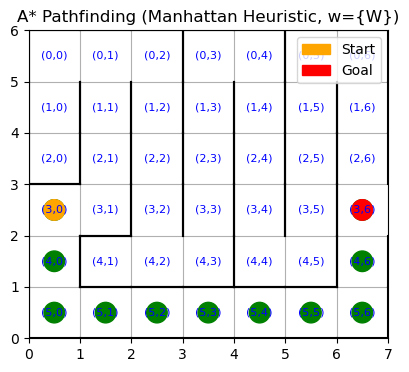

In [109]:
print("\nStep-by-step details with g(n), h(n), and cost:")
for prev, curr, cost in step_costs:
    g_val = g_score[curr]
    h_val = heuristic(curr, goal)
    print(f"{prev} → {curr}, cost = {cost}, g(n) = {g_val}, h(n) = {h_val}, f(n) = {g_val + W* h_val}")

# Pass only the path list to the draw function
draw_maze_with_path(maze, path)


<h2 style="color:purple"><u><b> Scenario 2 :: w= 2.5 </b></u></h2>


In [110]:
W = 2.5  # Heuristic weight

## Calling A* function

In [111]:
# three returned values
path, steps, total, scores = a_star_maze(maze, start, goal, W=2.5, rows=rows, cols=cols)

Step 1: Current = (3, 0), g(n)=0, h(n)=6, f(n)=15.0
Step 2: Current = (3, 1), g(n)=8, h(n)=5, f(n)=20.5
Step 3: Current = (4, 0), g(n)=3, h(n)=7, f(n)=20.5
Step 4: Current = (2, 1), g(n)=11, h(n)=6, f(n)=26.0
Step 5: Current = (5, 0), g(n)=6, h(n)=8, f(n)=26.0
Step 6: Current = (1, 1), g(n)=14, h(n)=7, f(n)=31.5
Step 7: Current = (5, 1), g(n)=14, h(n)=7, f(n)=31.5
Step 8: Current = (0, 1), g(n)=17, h(n)=8, f(n)=37.0
Step 9: Current = (5, 2), g(n)=22, h(n)=6, f(n)=37.0
Step 10: Current = (0, 0), g(n)=20, h(n)=9, f(n)=42.5
Step 11: Current = (0, 2), g(n)=25, h(n)=7, f(n)=42.5
Step 12: Current = (5, 3), g(n)=30, h(n)=5, f(n)=42.5
Step 13: Current = (1, 0), g(n)=23, h(n)=8, f(n)=43.0
Step 14: Current = (1, 2), g(n)=28, h(n)=6, f(n)=43.0
Step 15: Current = (2, 0), g(n)=26, h(n)=7, f(n)=43.5
Step 16: Current = (2, 2), g(n)=31, h(n)=5, f(n)=43.5
Step 17: Current = (3, 2), g(n)=34, h(n)=4, f(n)=44.0
Step 18: Current = (5, 4), g(n)=38, h(n)=4, f(n)=48.0
Step 19: Current = (4, 2), g(n)=37, h(n)=

##### Optimal Path details


Step-by-step details with g(n), h(n), and cost:
(3, 0) → (4, 0), cost = 3, g(n) = 3, h(n) = 7, f(n) = 20.5
(4, 0) → (5, 0), cost = 3, g(n) = 6, h(n) = 8, f(n) = 26.0
(5, 0) → (5, 1), cost = 8, g(n) = 14, h(n) = 7, f(n) = 31.5
(5, 1) → (5, 2), cost = 8, g(n) = 22, h(n) = 6, f(n) = 37.0
(5, 2) → (5, 3), cost = 8, g(n) = 30, h(n) = 5, f(n) = 42.5
(5, 3) → (5, 4), cost = 8, g(n) = 38, h(n) = 4, f(n) = 48.0
(5, 4) → (5, 5), cost = 8, g(n) = 46, h(n) = 3, f(n) = 53.5
(5, 5) → (5, 6), cost = 8, g(n) = 54, h(n) = 2, f(n) = 59.0
(5, 6) → (4, 6), cost = 3, g(n) = 57, h(n) = 1, f(n) = 59.5
(4, 6) → (3, 6), cost = 3, g(n) = 60, h(n) = 0, f(n) = 60.0


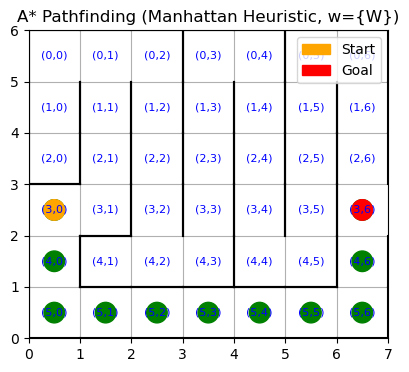

In [112]:

print("\nStep-by-step details with g(n), h(n), and cost:")
for prev, curr, cost in step_costs:
    g_val = g_score[curr]
    h_val = heuristic(curr, goal)
    print(f"{prev} → {curr}, cost = {cost}, g(n) = {g_val}, h(n) = {h_val}, f(n) = {g_val + W* h_val}")

# Pass only the path list to the draw function
draw_maze_with_path(maze, path)

 <h2 style="color:orange"><u><b>A* Algorithm Complexity</b></u></h2>

In [114]:
def print_astar_complexity(rows, cols, branching_factor=4):
    """
    Estimates and prints the time and space complexity of A* for a grid maze.
    """
    total_nodes = rows * cols
    print("----- A* Algorithm Complexity -----")
    print(f"Grid size: {rows} x {cols} = {total_nodes} nodes")

    # Time complexity: In worst case, A* may expand all nodes
    print(f"Time Complexity (worst-case): O(E) = O({total_nodes})")

    # Space complexity: stores open list (priority queue), g_score, came_from, closed_set
    print("Space Complexity:")
    print(f"- g_score: O(V) = O({total_nodes})")
    print(f"- came_from: O(V) = O({total_nodes})")
    print(f"- open_set (min-heap): O(V) = O({total_nodes})")
    print(f"- closed_set: O(V) = O({total_nodes})")

    print("=> Overall Space Complexity: O(V)")
    print("=> Overall Time Complexity: O(E), where E ≈ branching_factor × V")

# Example usage for 6x7 grid
print_astar_complexity(rows=6, cols=7)


----- A* Algorithm Complexity -----
Grid size: 6 x 7 = 42 nodes
Time Complexity (worst-case): O(E) = O(42)
Space Complexity:
- g_score: O(V) = O(42)
- came_from: O(V) = O(42)
- open_set (min-heap): O(V) = O(42)
- closed_set: O(V) = O(42)
=> Overall Space Complexity: O(V)
=> Overall Time Complexity: O(E), where E ≈ branching_factor × V


<h2 style="color: #2c3e50;"><b>Search Algorithm Comparison for Maze-Navigating Robot Agent</b></h2>



<table border="1" style="border-collapse: collapse; width: 100%; font-size: 14px;">
  <tr style="background-color: #e6e6e6;">
    <th style="padding: 6px; text-align: left;">Algorithm</th>
    <th style="padding: 6px; text-align: left;">Heuristic</th>
    <th style="padding: 6px; text-align: left;">Path Cost(g(n))</th>
    <th style="padding: 6px; text-align: left;">Optimal Solution</th>
    <th style="padding: 6px; text-align: left;">Performance on This Maze</th>
    <th style="padding: 6px; text-align: left;">Remarks</th>
  </tr>

  <tr>
    <td style="padding: 6px;"><b>A*</b></td>
    <td>Yes</td>
    <td>Yes</td>
    <td>Yes</td>
    <td>Best choice</td>
    <td>Balances path cost and goal direction using f(n) = g(n) + h(n).</td>
  </tr>

  <tr>
    <td style="padding: 6px;"><b>Greedy Best-First</b></td>
    <td>Yes</td>
    <td>No</td>
    <td>No</td>
    <td>Fast but may be inaccurate</td>
    <td>Ignores actual move cost, likely to take East-heavy paths incorrectly.</td>
  </tr>

  <tr>
    <td style="padding: 6px;"><b>Breadth-First Search</b></td>
    <td>No</td>
    <td>Assumes unit cost</td>
    <td>Only for uniform cost</td>
    <td>Not suited</td>
    <td>Doesn’t handle varying costs like East penalty.</td>
  </tr>

  <tr>
    <td style="padding: 6px;"><b>Depth-First Search</b></td>
    <td>No</td>
    <td>No</td>
    <td>No</td>
    <td>Worst fit</td>
    <td>May explore deep costly paths without considering cost or goal proximity.</td>
  </tr>

  <tr>
    <td style="padding: 6px;"><b>Bidirectional A*</b></td>
    <td>Yes (both ends)</td>
    <td>Yes</td>
    <td>Yes</td>
    <td>Potentially faster (complex to implement)</td>
    <td>Can be faster if both directions use good heuristics; harder to coordinate.</td>
  </tr>
</table>


<h2 style="text-align: center; color: darkgreen; margin-top: 40px;">_____END_____</h2>